In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

### raw 파일 경로

In [3]:
ACCIDENT_PATH = "raw/교통사고통계_사고유형별.csv"
LAW_PATH = "raw/교통사고통계_법규위반별.csv"
TIMELINE_PATH = "raw/교통사고통계_시간대별.csv"

df_accident = pd.read_csv(ACCIDENT_PATH, encoding="utf-8")
df_law = pd.read_csv(LAW_PATH, encoding="utf-8")
df_timeline = pd.read_csv(TIMELINE_PATH, encoding="utf-8", header=[0, 1])

years = ['2020', '2021', '2022', '2023', '2024']

In [4]:
df_accident.head()

,사고유형 대분류,사고유형 중분류,분류,2020,2021,2022,2023,2024
0,차대사람,횡단중,사고[건],186.0,211.0,245.0,213.0,217.0
1,차대사람,횡단중,사망[명],1.0,2.0,0.0,0.0,1.0
2,차대사람,횡단중,부상[명],195.0,217.0,250.0,219.0,225.0
3,차대사람,차도통행중,사고[건],18.0,34.0,27.0,35.0,24.0
4,차대사람,차도통행중,사망[명],0.0,0.0,0.0,0.0,1.0


In [5]:
df_accident.index = [df_accident.iloc[:, 0], df_accident.iloc[:, 1], df_accident.iloc[:, 2]]

df_accident.head()

사고유형 대분류 사고유형 중분류     분류   2020   2021   2022   2023  \
사고유형 대분류 사고유형 중분류 분류                                                           
차대사람     횡단중      사고[건]     차대사람      횡단중  사고[건]  186.0  211.0  245.0  213.0   
                  사망[명]     차대사람      횡단중  사망[명]    1.0    2.0    0.0    0.0   
                  부상[명]     차대사람      횡단중  부상[명]  195.0  217.0  250.0  219.0   
         차도통행중    사고[건]     차대사람    차도통행중  사고[건]   18.0   34.0   27.0   35.0   
                  사망[명]     차대사람    차도통행중  사망[명]    0.0    0.0    0.0    0.0   

                          2024  
사고유형 대분류 사고유형 중분류 분류            
차대사람     횡단중      사고[건]  217.0  
                  사망[명]    1.0  
                  부상[명]  225.0  
         차도통행중    사고[건]   24.0  
                  사망[명]    1.0

In [6]:
df = df_accident.copy()
df.columns = ['대분류', '중분류', '분류'] + years

df = df[df['분류'] == '사고[건]']
df = df.sort_values(['대분류', '중분류'])

df_grouped = df.set_index(['대분류', '중분류'])[years]

df_percent = df_grouped.div(df_grouped.sum(), axis=1)
df_count = df_grouped.sum()

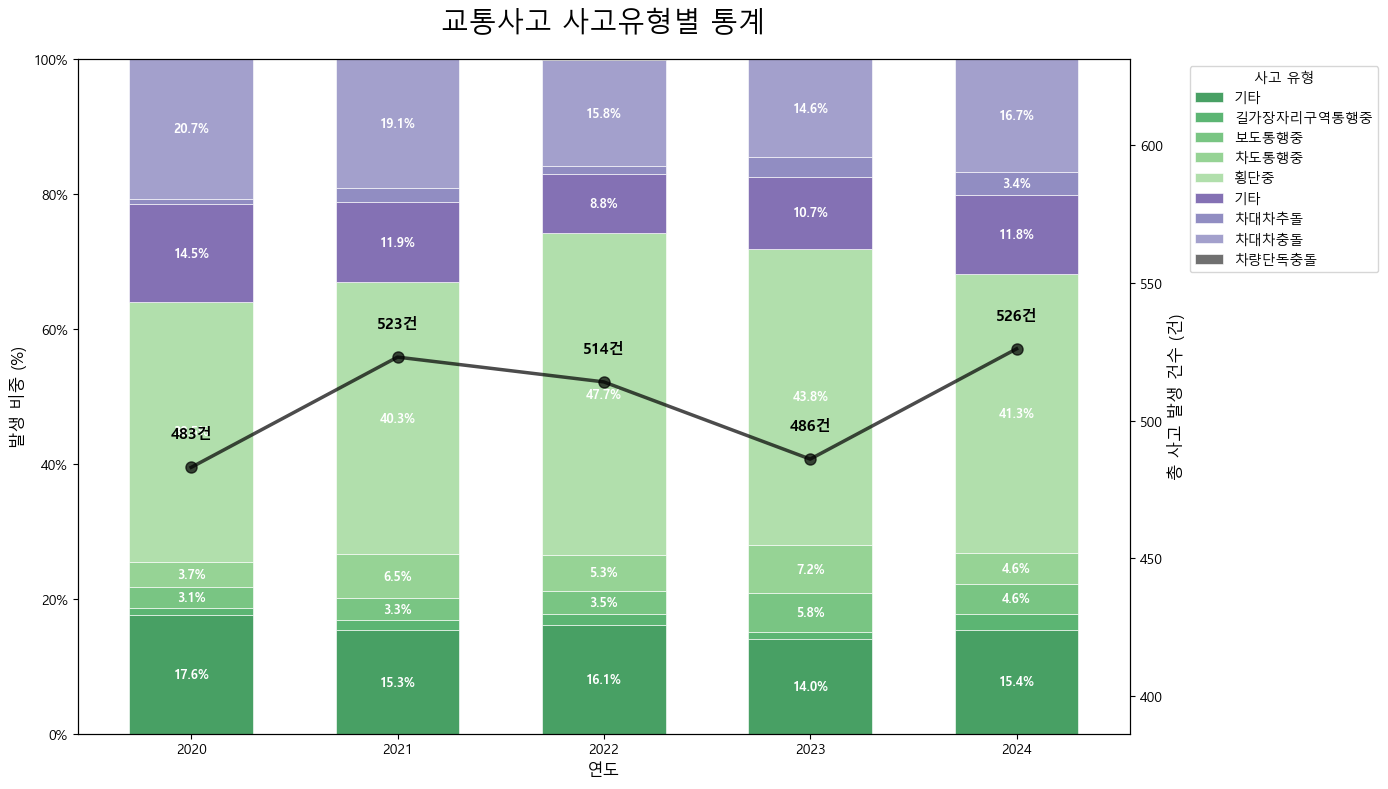

In [7]:
palettes = {
    '차대사람': sns.color_palette("Greens", 10),
    '차대차': sns.color_palette("Purples", 10),
    '차량단독': sns.color_palette("Greys", 10),
}

color_map = []
for main_cat, sub_cat in df_percent.index:
    palette = palettes.get(main_cat)

    idx = list(df[df['대분류'] == main_cat]['중분류']).index(sub_cat)
    color_map.append(palette[-(idx+3)])

fig, ax1 = plt.subplots(figsize=(14, 8))

plot_df = df_percent.copy()
plot_df.index = plot_df.index.get_level_values('중분류')

plot_df.T.plot(kind='bar', stacked=True, ax=ax1, color=color_map, width=0.6, alpha=0.85, edgecolor='white', linewidth=0.5)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)) # %로 바꿔줌

ax1.set_ylabel('발생 비중 (%)', fontsize=12)
ax1.set_xlabel('연도', fontsize=12)
ax1.set_xticklabels(years, rotation=0)

ax2 = ax1.twinx()
ax2.plot(years, df_count, color='black', marker='o', markersize=8, linewidth=2.5, label='총 사고 건수', alpha=0.7)
ax2.set_ylabel('총 사고 발생 건수 (건)', fontsize=12)
ax2.set_ylim(df_count.min() * 0.8, df_count.max() * 1.2)

for p in ax1.patches:
    h = p.get_height()
    if h > 0.03:
        ax1.text(p.get_x() + p.get_width()/2, p.get_xy()[1] + h/2, f'{h*100:.1f}%', ha='center', va='center', color='white', fontsize=9, fontweight='bold')

for i, val in enumerate(df_count):
    ax2.text(i, val + (df_count.max()*0.02), f'{int(val):,}건', ha='center', color='black', fontweight='bold', fontsize=11)

ax1.legend(title='사고 유형', bbox_to_anchor=(1.05, 1))

plt.title('교통사고 사고유형별 통계', fontsize=20, pad=20)
plt.tight_layout()

plt.savefig("연도별 사고 사고유형별.png")
plt.show()

In [8]:
years_columns = [col for col in df.columns if str(col).isdigit()]

df['total_sum'] = df[years_columns].apply(pd.to_numeric, errors='coerce').sum(axis=1)

top_3_types = df.sort_values(by='total_sum', ascending=False).head(3)

print("--- [전체 사고유형 TOP 3] ---")
all_total = df['total_sum'].sum()

for i, (_, row) in enumerate(top_3_types.iterrows(), 1):
    percentage = (row['total_sum'] / all_total) * 100
    print(f"{i}위: {row['중분류']} ({int(row['total_sum']):,}- {row['대분류']} 계열, 비중 {percentage:.1f}%)")

--- [전체 사고유형 TOP 3] ---
1위: 횡단중 (1,072- 차대사람 계열, 비중 42.3%)
2위: 차대차충돌 (440- 차대차 계열, 비중 17.4%)
3위: 기타 (397- 차대사람 계열, 비중 15.7%)


In [9]:
df = df_law.copy()
df.columns = ['법규위반', '분류'] + years

df = df[df['분류'] == '사고[건]']
df = df.sort_values('법규위반')

df_percent = df_grouped.div(df_grouped.sum(), axis=1)
df_count = df_grouped.sum()

In [10]:
df_law.head()

,가해운전자(1당) 법규위반,분류,2020,2021,2022,2023,2024
0,과속,사고[건],4.0,0.0,0.0,0.0,0.0
1,과속,사망[명],0.0,0.0,0.0,0.0,0.0
2,과속,부상[명],6.0,0.0,0.0,0.0,0.0
3,중앙선 침범,사고[건],7.0,3.0,6.0,9.0,3.0
4,중앙선 침범,사망[명],2.0,0.0,0.0,1.0,0.0


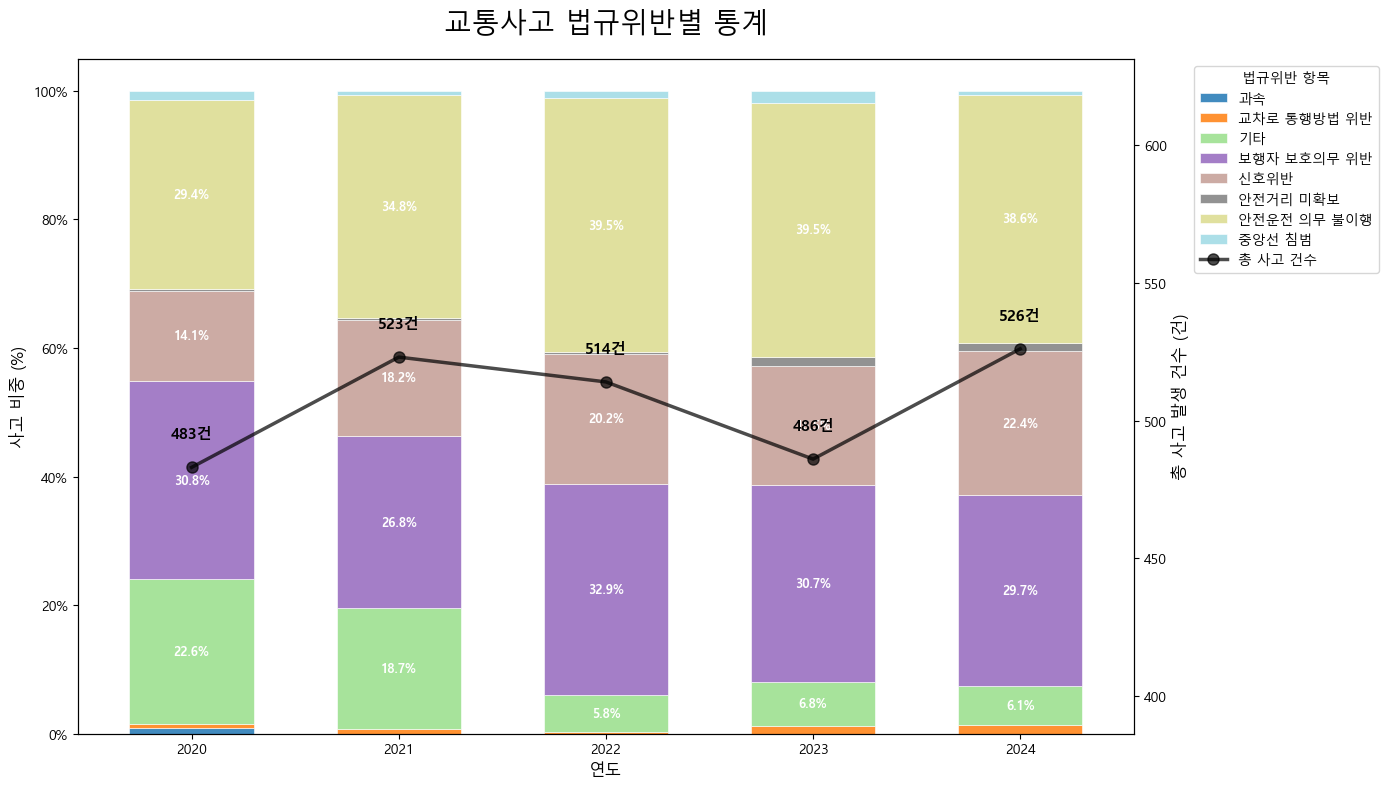

In [11]:
df_t = df.set_index('법규위반')[years].T

df_percent = df_t.div(df_t.sum(axis=1), axis=0)
df_count = df_t.sum(axis=1)

fig, ax1 = plt.subplots(figsize=(14, 8))

df_percent.plot(kind='bar', stacked=True, ax=ax1, colormap='tab20', 
                width=0.6, alpha=0.85, edgecolor='white', linewidth=0.5)

ax1.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax1.set_ylabel('사고 비중 (%)', fontsize=12)
ax1.set_xlabel('연도', fontsize=12)
ax1.set_xticklabels(years, rotation=0)

ax2 = ax1.twinx()
ax2.plot(years, df_count, color='black', marker='o', markersize=8, linewidth=2.5, label='총 사고 건수', alpha=0.7)
ax2.set_ylabel('총 사고 발생 건수 (건)', fontsize=12)
ax2.set_ylim(df_count.min() * 0.8, df_count.max() * 1.2)
ax2.grid(False)

for p in ax1.patches:
    h = p.get_height()
    if h > 0.03:
        ax1.text(p.get_x() + p.get_width()/2, p.get_xy()[1] + h/2, f'{h*100:.1f}%', 
                 ha='center', va='center', color='white', fontsize=9, fontweight='bold')

for i, val in enumerate(df_count):
    ax2.text(i, val + (df_count.max()*0.02), f'{int(val):,}건', ha='center', color='black', fontweight='bold', fontsize=11)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, title='법규위반 항목', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.title('교통사고 법규위반별 통계', fontsize=20, pad=20)
plt.tight_layout()

plt.savefig("연도별 사고 법규위반별.png")
plt.show()

In [12]:
total_by_law = df_t.sum().sort_values(ascending=False)

top_3_laws = total_by_law.head(3)

print("--- [전체 법규위반 TOP 3] ---")
for i, (law, count) in enumerate(top_3_laws.items(), 1):
    percentage = (count / total_by_law.sum()) * 100
    print(f"{i}위: {law} ({int(count):,}건, 비중 {percentage:.1f}%)")

--- [전체 법규위반 TOP 3] ---
1위: 안전운전 의무 불이행 (922건, 비중 36.4%)
2위: 보행자 보호의무 위반 (763건, 비중 30.1%)
3위: 신호위반 (475건, 비중 18.8%)


In [12]:
df_timeline.head()

요일     연도  2020                                                       ...  \
  요일     연도 2시~4시 4시~6시 8시~10시 10시~12시 12시~14시 14시~16시 16시~18시 18시~20시  ...   
0  일  사고[건]   0.0   0.0    0.0     2.0     6.0     5.0     8.0     4.0  ...   
1  일  사망[명]   0.0   0.0    0.0     0.0     0.0     0.0     0.0     0.0  ...   
2  일  부상[명]   0.0   0.0    0.0     2.0     6.0     5.0     9.0     4.0  ...   
3  월  사고[건]   0.0   0.0    4.0     4.0    12.0    23.0    19.0    12.0  ...   
4  월  사망[명]   0.0   0.0    0.0     0.0     0.0     1.0     0.0     0.0  ...   

   2024                                                                       
  2시~4시 6시~8시 8시~10시 10시~12시 12시~14시 14시~16시 16시~18시 18시~20시 20시~22시 22시~24시  
0   0.0   0.0    0.0     6.0     4.0     4.0    11.0     5.0     1.0     0.0  
1   0.0   0.0    0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0  
2   0.0   0.0    0.0     7.0     4.0     4.0    11.0     5.0     1.0     0.0  
3   0.0   3.0   17.0     1.0    11.0    19.0    22.0     8.0     8.0     1.0  
4   0.0   0.0    0.0     0.0     0.0     0.0     1.0     0.0     0.0     0.0  

[5 rows x 49 columns]

In [13]:
df = df_timeline.copy()
df.columns.values[0] = ('요일', '요일')
df.columns.values[1] = ('분류', '분류')
df.columns = pd.MultiIndex.from_tuples(df.columns)

df = df[df[('분류', '분류')] == '사고[건]']

df_melted = df.melt(id_vars=[('요일', '요일'), ('분류', '분류')], var_name=['연도', '시간대'], value_name='사고건수')
df_melted.columns = ['요일', '분류', '연도', '시간대', '사고건수']

day_order = ['월', '화', '수', '목', '금', '토', '일']
df_melted['요일'] = pd.Categorical(df_melted['요일'], categories=day_order, ordered=True)

time_order = sorted(df_melted['시간대'].unique())
df_melted['시간대'] = pd.Categorical(df_melted['시간대'], categories=time_order, ordered=True)

df_pivot = df_melted.pivot_table(index='시간대', columns='요일', values='사고건수', aggfunc='sum')

In [14]:
# 1. 데이터 불러오기 (첫 두 줄이 헤더 역할을 하므로 skip하고 직접 컬럼 지정 권장)
# 시간대별 파일은 구조가 특이해서 iloc로 필요한 데이터 영역만 가져오는게 안전합니다.
df_time = pd.read_csv(TIMELINE_PATH, encoding="utf-8")

# 2. '사고[건]' 데이터만 필터링 (2번째 컬럼이 '연도/분류' 역할을 함)
df_time_acc = df_time[df_time.iloc[:, 1] == '사고[건]'].copy()

# 3. 시간대별 컬럼(3번 컬럼부터 끝까지)만 합산
# 이 데이터는 2020~2024년이 가로로 나열되어 있으므로 시간대별로 그룹화하여 합칩니다.
time_columns = df_time.columns[2:]  # 시간대 이름들이 들어있는 컬럼들
df_time_sum = df_time_acc[time_columns].apply(pd.to_numeric, errors='coerce').sum()

# 4. 시간대 이름이 '2020.1', '2020.2' 처럼 깨져있을 수 있으므로 다시 매핑
# 실제 시간대 순서 (파일 구조에 나타난 순서대로)
time_labels = ['00시~02시', '02시~04시', '04시~06시', '06시~08시', '08시~10시', 
               '10시~12시', '12시~14시', '14시~16시', '16시~18시', '18시~20시', 
               '20시~22시', '22시~24시']

# 연도별로 반복되는 시간대 데이터를 하나로 통합 (예: 모든 연도의 00-02시 합계)
time_data = {}
for label in time_labels:
    # 컬럼명에 해당 시간대 문자열이 포함된 것들의 합을 구함
    cols = [c for c in time_columns if label in str(c) or df_time.iloc[0][c] == label]
    time_data[label] = df_time_acc[cols].apply(pd.to_numeric).sum().sum()

df_final_time = pd.Series(time_data)

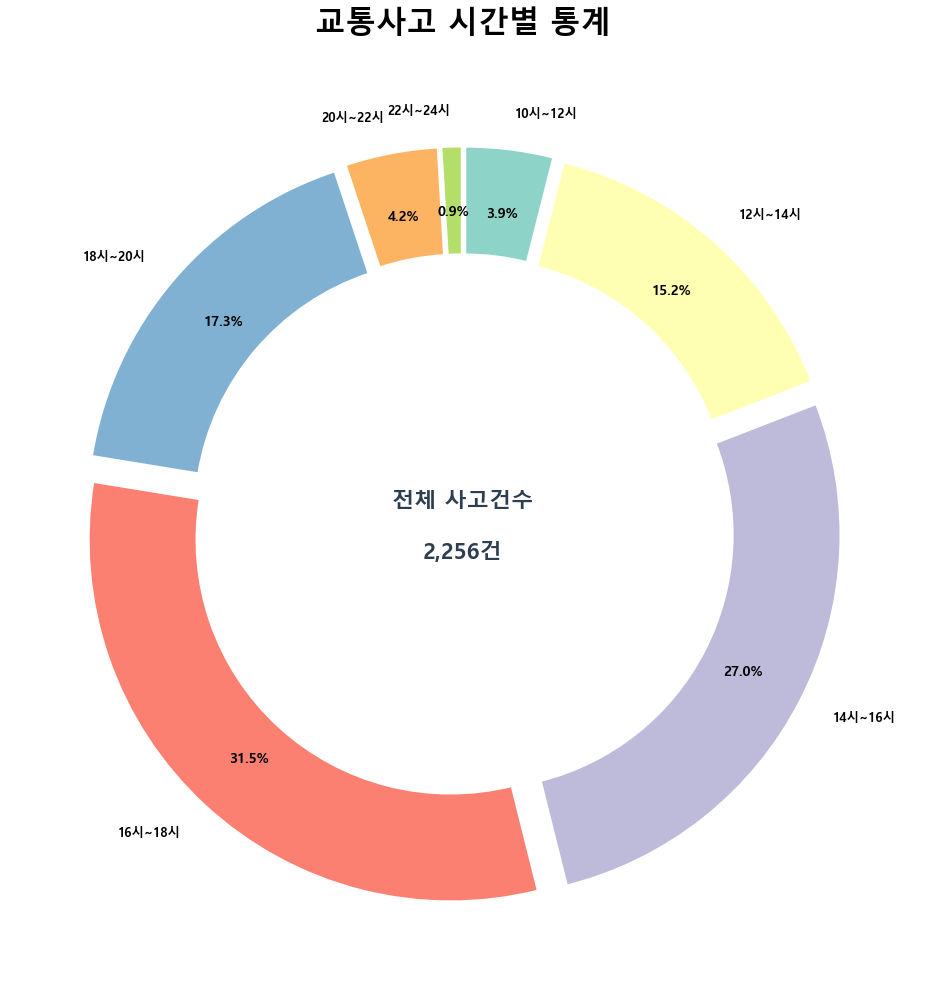

In [15]:
# 1. 0건 제외
df_pie = df_final_time[df_final_time > 0].copy()

# 2. ★핵심★: time_labels 순서대로 카테고리 형식을 지정해서 순서를 고정합니다.
# 이렇게 하면 sort_index() 호출 시 우리가 정의한 시간 순서대로 정렬됩니다.
df_pie.index = pd.Categorical(df_pie.index, categories=time_labels, ordered=True)
df_pie = df_pie.sort_index()

# 3. 시각화 설정
plt.figure(figsize=(10, 10)) # 8, 8보다 조금 더 키우는게 라벨 가독성에 좋습니다.
colors = sns.color_palette("Set3", len(df_pie))

# 4. 도넛 차트 그리기
patches, texts, autotexts = plt.pie(
    df_pie, 
    labels=df_pie.index, 
    autopct='%1.1f%%', 
    startangle=90,      # 90도로 설정하면 00시(첫 데이터)가 12시 방향에서 시작합니다.
    counterclock=False, # 시계 방향으로 흐르게 설정
    colors=colors,
    pctdistance=0.82,
    explode=[0.05] * len(df_pie),
    wedgeprops={'width': 0.3, 'edgecolor': 'w', 'linewidth': 2}
)

# 텍스트 스타일링
plt.setp(texts, size=9, fontweight='bold')
plt.setp(autotexts, size=10, fontweight='bold')

# 중앙에 총 건수 표시
total_val = int(df_pie.sum())
plt.text(0, 0, f'전체 사고건수\n\n{total_val:,}건', 
         ha='center', va='center', fontsize=16, fontweight='bold', color='#2C3E50')

plt.title('교통사고 시간별 통계', fontsize=22, pad=30, fontweight='bold')

plt.tight_layout()
plt.savefig("연도별 사고 시간별.png")
plt.show()

In [1]:
day_data = df_time_acc.groupby(df_time_acc.iloc[:, 0])[time_columns].apply(lambda x: x.apply(pd.to_numeric, errors='coerce').sum().sum())

# 2. 요일 순서 정렬 (월~일 순서로 고정)
day_order = ['월', '화', '수', '목', '금', '토', '일']
day_data = day_data.reindex(day_order)

# 3. 시각화 시작
plt.figure(figsize=(12, 7))

# 요일별로 색상을 다르게 주어 시각적 효과 부여
colors = sns.color_palette("husl", len(day_data))
ax = day_data.plot(kind='bar', color=colors, width=0.7, alpha=0.8, edgecolor='black', linewidth=1)

# 수치 표시 (막대 위에 건수 표시)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}건', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')

# 그래프 꾸미기
plt.title('교통사고 요일별 통계', fontsize=20, pad=25, fontweight='bold')
plt.xlabel('요일', fontsize=13, fontweight='bold')
plt.ylabel('사고 발생 건수 (건)', fontsize=13, fontweight='bold')
plt.xticks(rotation=0, fontsize=12) # 요일은 가로로 똑바로 표시
plt.ylim(0, day_data.max() * 1.15) # 수치 표시를 위한 상단 여유

# 배경 그리드 추가
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("사고 요일별.png")
plt.show()

NameError: name 'df_time_acc' is not defined

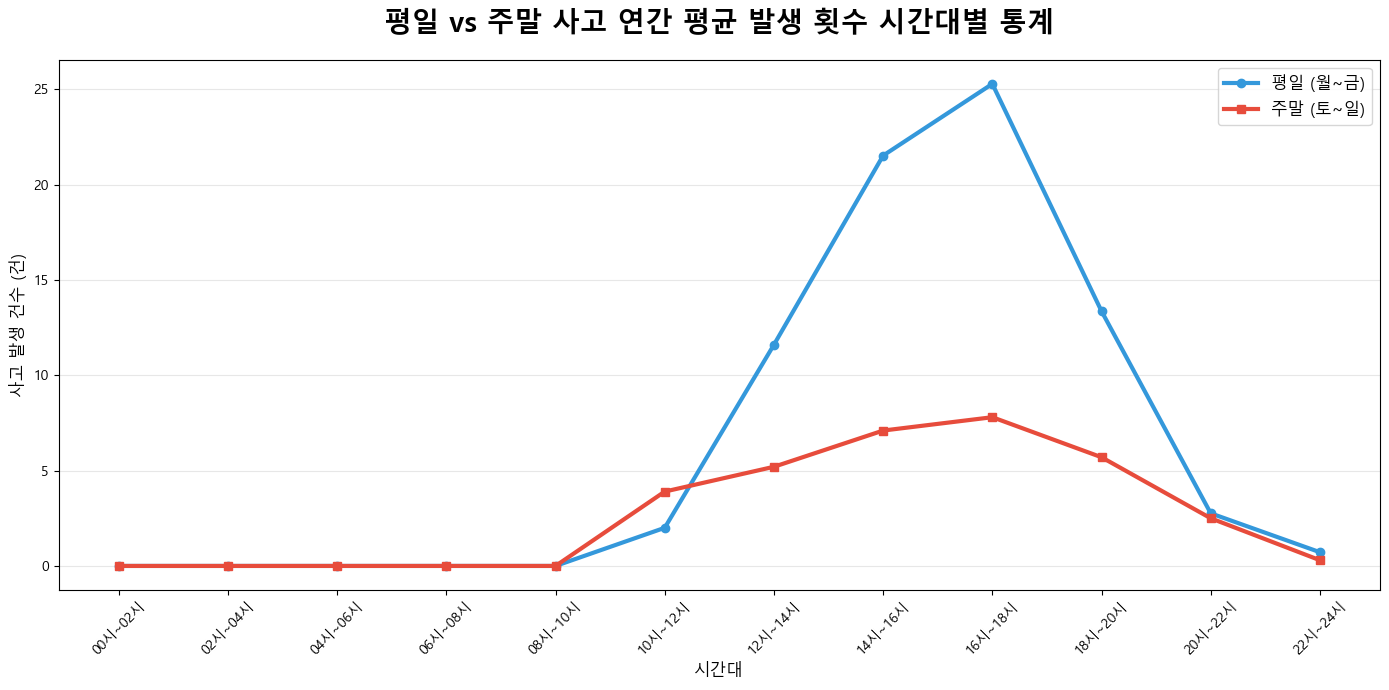

In [17]:
# 1. 데이터 준비 및 df_compare 변수 생성
weekday_list = ['월', '화', '수', '목', '금']
weekend_list = ['토', '일']
comparison_data = []

# 앞서 정의한 time_labels 순서대로 데이터를 모읍니다.
for label in time_labels:
    cols = [c for c in time_columns if label in str(c) or df_time.iloc[0][c] == label]
    
    # 평일/주말 데이터 추출 및 합산
    weekday_avg = df_time_acc[df_time_acc.iloc[:, 0].isin(weekday_list)][cols].apply(pd.to_numeric, errors='coerce').sum().sum() / 5 / 5
    weekend_avg = df_time_acc[df_time_acc.iloc[:, 0].isin(weekend_list)][cols].apply(pd.to_numeric, errors='coerce').sum().sum() / 2 / 5
    
    comparison_data.append({'시간대': label, '평일': weekday_avg, '주말': weekend_avg})

# 변수 생성 확정
df_compare = pd.DataFrame(comparison_data).set_index('시간대')

# 2. 시각화 시작
plt.figure(figsize=(14, 7))

# 선 그래프 그리기
plt.plot(df_compare.index, df_compare['평일'], marker='o', linewidth=3, color='#3498db', label='평일 (월~금)')
plt.plot(df_compare.index, df_compare['주말'], marker='s', linewidth=3, color='#e74c3c', label='주말 (토~일)')

plt.title('평일 vs 주말 사고 연간 평균 발생 횟수 시간대별 통계', fontsize=20, pad=20, fontweight='bold')
plt.xlabel('시간대', fontsize=12)
plt.ylabel('사고 발생 건수 (건)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(fontsize=12)
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("사고 평일vs주말 시간대별.png")
plt.show()

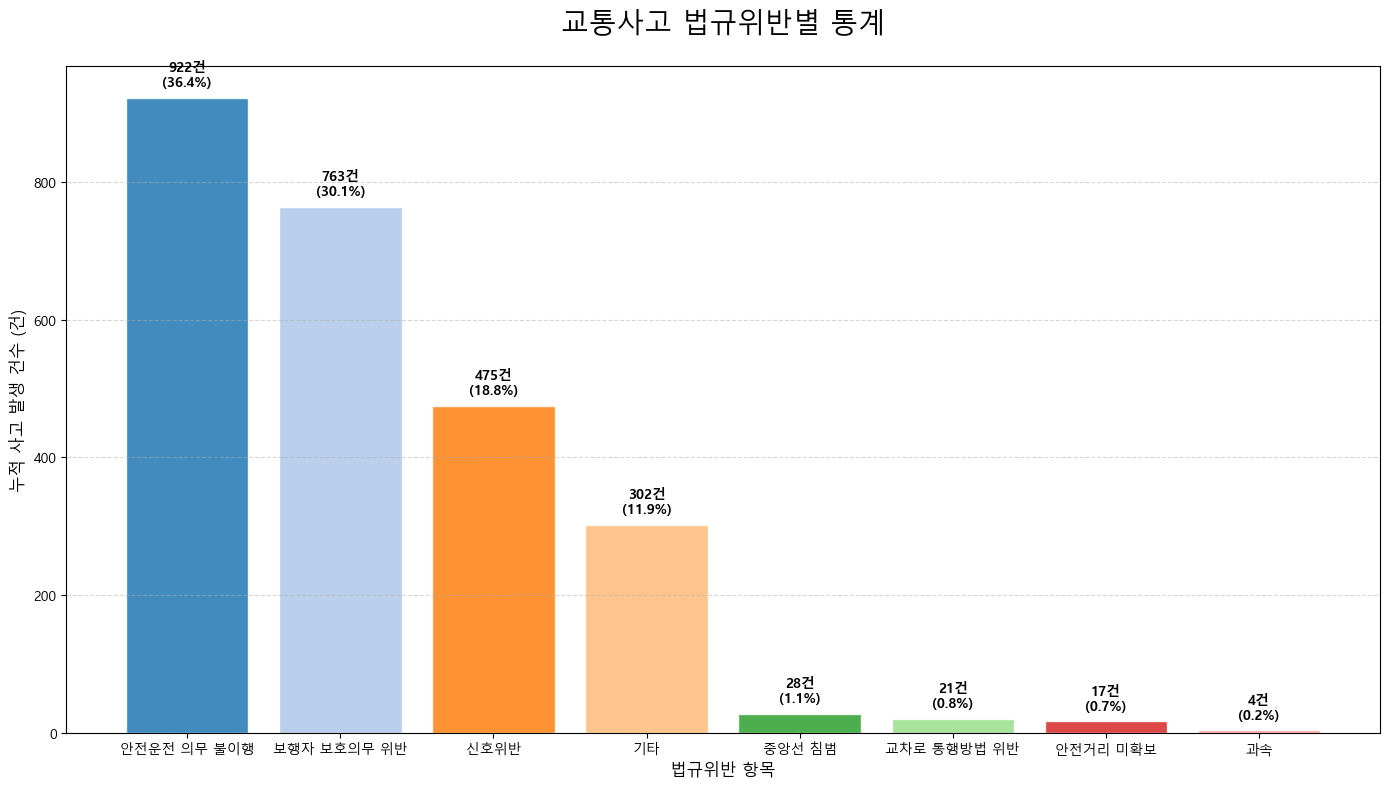

In [18]:
df_total_sum = df_t.sum().sort_values(ascending=False)
total_val = df_total_sum.sum()

# 2. 그래프 생성
fig, ax = plt.subplots(figsize=(14, 8))

# 세로 막대 그래프 (Palettes는 tab20을 사용하여 구분감을 줌)
colors = sns.color_palette("tab20", len(df_total_sum))
bars = ax.bar(df_total_sum.index, df_total_sum.values, color=colors, alpha=0.85, edgecolor='white')

# 각 막대 상단에 건수와 % 표시
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + (total_val * 0.005), 
             f'{int(height):,}건\n({(height/total_val)*100:.1f}%)', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 디자인 디테일 설정
ax.set_title('교통사고 법규위반별 통계', fontsize=20, pad=25)
ax.set_ylabel('누적 사고 발생 건수 (건)', fontsize=12)
ax.set_xlabel('법규위반 항목', fontsize=12)

# 항목명이 길 경우를 대비해 45도 회전
ax.set_xticks(range(len(df_total_sum)))
ax.set_xticklabels(df_total_sum.index)

# 그리드 설정 (y축만)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

# 저장 및 출력
plt.savefig("교통사고 법규위반별 통계.png", dpi=300, bbox_inches='tight')
plt.show()

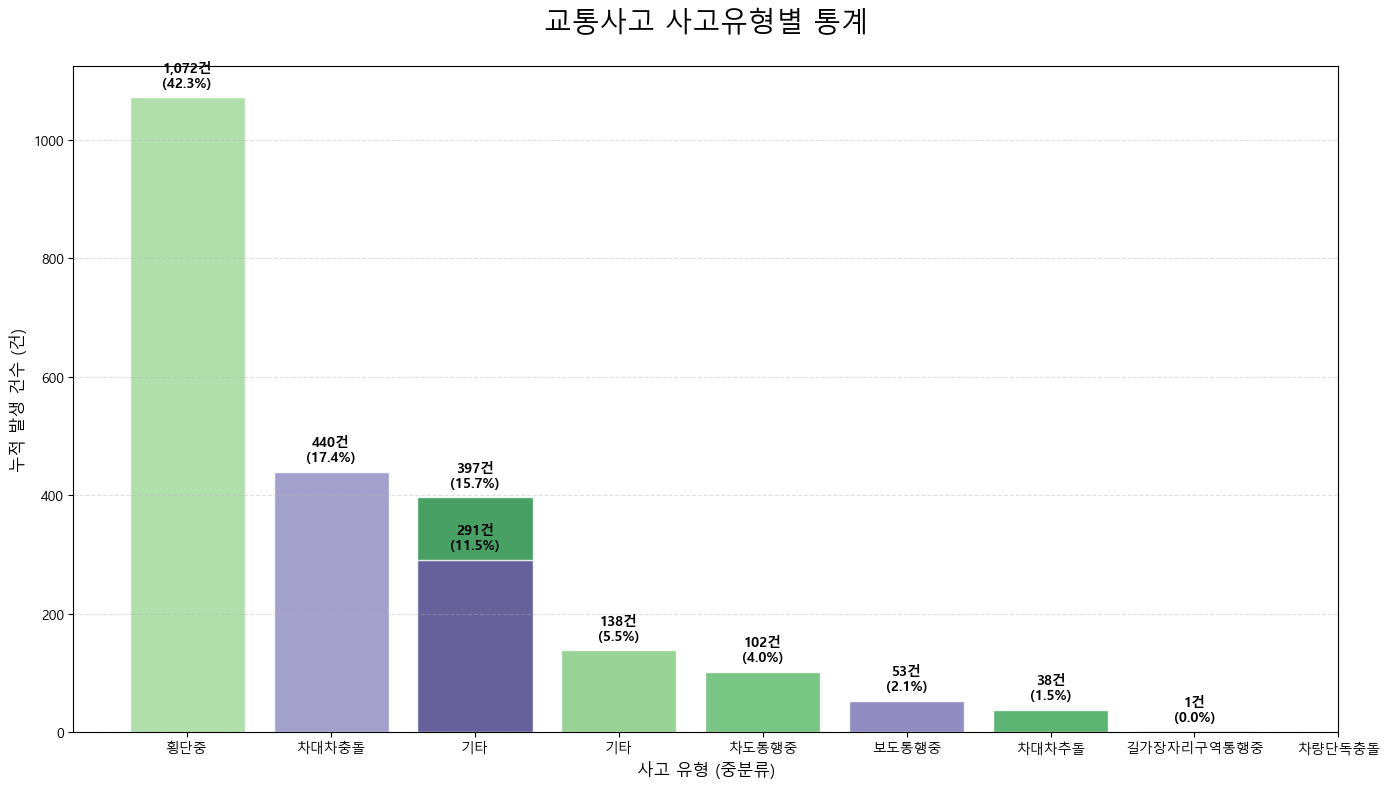

In [19]:
df = df_accident.copy()
df.columns = ['대분류', '중분류', '분류'] + years

df = df[df['분류'] == '사고[건]']
df = df.sort_values(['대분류', '중분류'])

df_grouped = df.set_index(['대분류', '중분류'])[years]

df_percent = df_grouped.div(df_grouped.sum(), axis=1)
df_count = df_grouped.sum()

df_total = df_grouped.sum(axis=1).sort_values(ascending=False)
total_val = df_total.sum()

# 2. 기존 컬러맵 재구성 (정렬된 순서에 맞게 색상 매칭)
# df_total의 인덱스는 (대분류, 중분류) 튜플 형태입니다.
final_colors = []
for main_cat, sub_cat in df_total.index:
    palette = palettes.get(main_cat)
    # 해당 대분류 내에서 몇 번째 중분류인지 확인하여 색상 선택
    sub_list = list(df[df['대분류'] == main_cat]['중분류'])
    idx = sub_list.index(sub_cat)
    final_colors.append(palette[-(idx+3)])

# 3. 그래프 생성
fig, ax = plt.subplots(figsize=(14, 8))

# 인덱스를 '중분류'만 표시하도록 변경하여 막대 생성
plot_labels = [idx[1] for idx in df_total.index]
bars = ax.bar(plot_labels, df_total.values, color=final_colors, alpha=0.85, edgecolor='white')

# 수치 표시 (건수 및 %)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + (total_val * 0.005), 
             f'{int(height):,}건\n({(height/total_val)*100:.1f}%)', 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# 디자인 설정
ax.set_title('교통사고 사고유형별 통계', fontsize=20, pad=25)
ax.set_ylabel('누적 발생 건수 (건)', fontsize=12)
ax.set_xlabel('사고 유형 (중분류)', fontsize=12)
ax.set_xticks(range(len(plot_labels)))
ax.set_xticklabels(plot_labels)

# 그리드 추가
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

# 저장 및 출력
plt.savefig("교통사고 사고유형별 통계.png", dpi=300, bbox_inches='tight')
plt.show()